In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor

In [2]:
df = pd.read_json("KAG_Appliance_energydata.json")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (19735, 29)


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [3]:
print("Shape:", df.shape)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Shape: (19735, 29)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         19735 non-null  datetime64[us]
 1   Appliances   19735 non-null  int64         
 2   lights       19735 non-null  int64         
 3   T1           19735 non-null  float64       
 4   RH_1         19735 non-null  float64       
 5   T2           19735 non-null  float64       
 6   RH_2         19735 non-null  float64       
 7   T3           19735 non-null  float64       
 8   RH_3         19735 non-null  float64       
 9   T4           19735 non-null  float64       
 10  RH_4         19735 non-null  float64       
 11  T5           19735 non-null  float64       
 12  RH_5         19735 non-null  float64       
 13  T6           19735 non-null  float64       
 14  RH_6         19735 non-null  float64       
 15  T7           19735 non-

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,2016-03-20 05:29:59.999999,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,...,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
min,2016-01-11 17:00:00,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,2016-02-14 23:15:00,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,...,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,2016-03-20 05:30:00,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,...,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,2016-04-23 11:45:00,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,...,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,2016-05-27 18:00:00,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530
std,NaN,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,...,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634



Missing Values:
date           0
Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64

Duplicate Rows:
0

Data Types:
date           datetime64[us]
Appliances              int64
lights                  int64
T1                    float64
RH_1                  float64
T2                    float64
RH_2                  float64
T3                    float64
RH_3                  float64
T4                    float64
RH_4                  float64
T5                    float64
RH_5                  float64
T6                    float64
RH_6                  flo

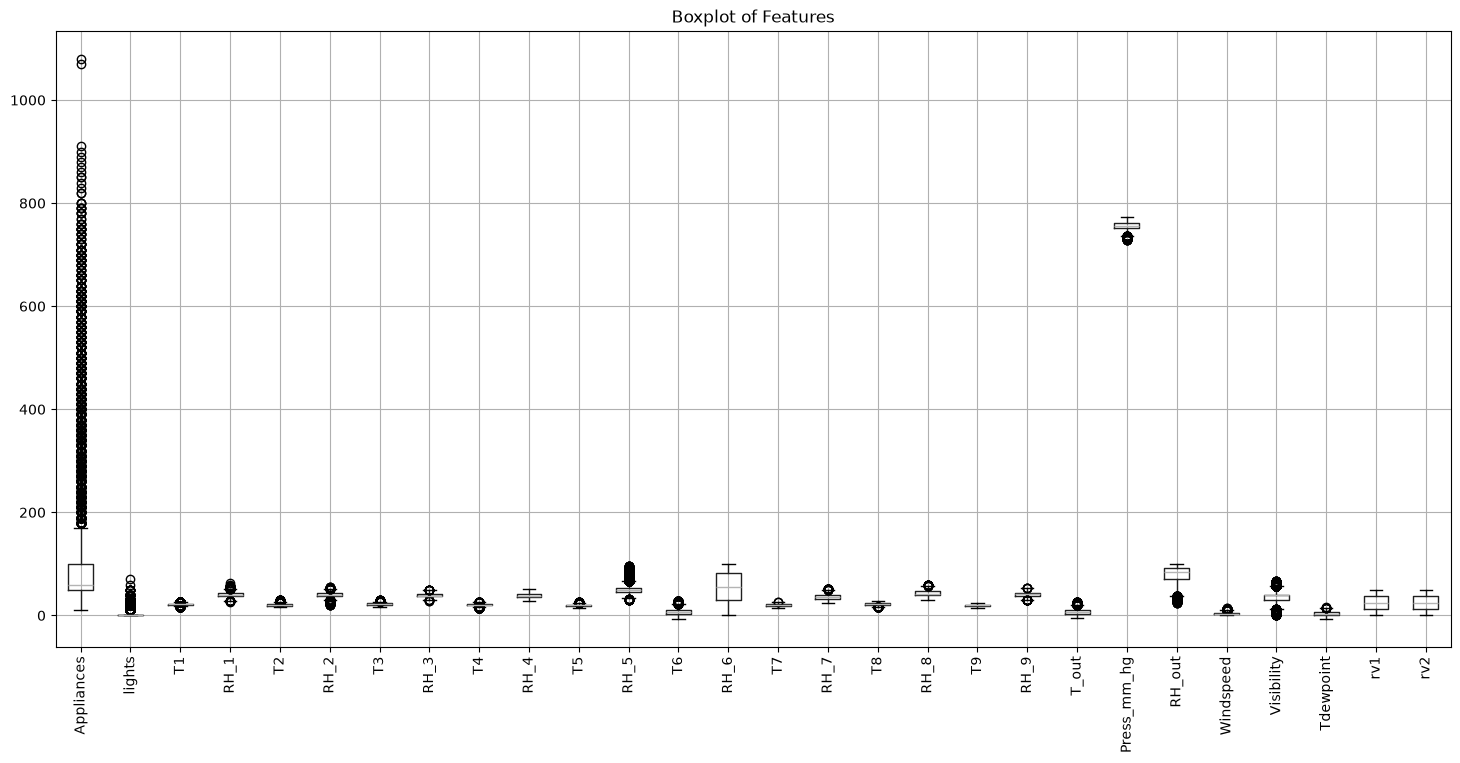

In [4]:
df.boxplot(figsize=(18, 8))

plt.xticks(rotation=90)
plt.title("Boxplot of Features")
plt.show()

In [5]:
df['date'] = pd.to_datetime(df['date'])

df['Hour'] = df['date'].dt.hour
df['Day'] = df['date'].dt.day
df['Month'] = df['date'].dt.month
df['Weekday'] = df['date'].dt.weekday

df['Weekend'] = df['Weekday'].apply(
    lambda x: 1 if x >= 5 else 0
)

df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,Windspeed,Visibility,Tdewpoint,rv1,rv2,Hour,Day,Month,Weekday,Weekend
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,7.000000,63.000000,5.3,13.275433,13.275433,17,11,1,0,0
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,6.666667,59.166667,5.2,18.606195,18.606195,17,11,1,0,0
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,6.333333,55.333333,5.1,28.642668,28.642668,17,11,1,0,0
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,6.000000,51.500000,5.0,45.410389,45.410389,17,11,1,0,0
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,5.666667,47.666667,4.9,10.084097,10.084097,17,11,1,0,0


In [6]:
# Cyclic time features

df['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)

df['Weekday_sin'] = np.sin(2 * np.pi * df['Weekday'] / 7)
df['Weekday_cos'] = np.cos(2 * np.pi * df['Weekday'] / 7)

df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,Day,Month,Weekday,Weekend,Hour_sin,Hour_cos,Weekday_sin,Weekday_cos,Month_sin,Month_cos
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,11,1,0,0,-0.965926,-0.258819,0.0,1.0,0.5,0.866025
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,11,1,0,0,-0.965926,-0.258819,0.0,1.0,0.5,0.866025
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,11,1,0,0,-0.965926,-0.258819,0.0,1.0,0.5,0.866025
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,11,1,0,0,-0.965926,-0.258819,0.0,1.0,0.5,0.866025
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,11,1,0,0,-0.965926,-0.258819,0.0,1.0,0.5,0.866025


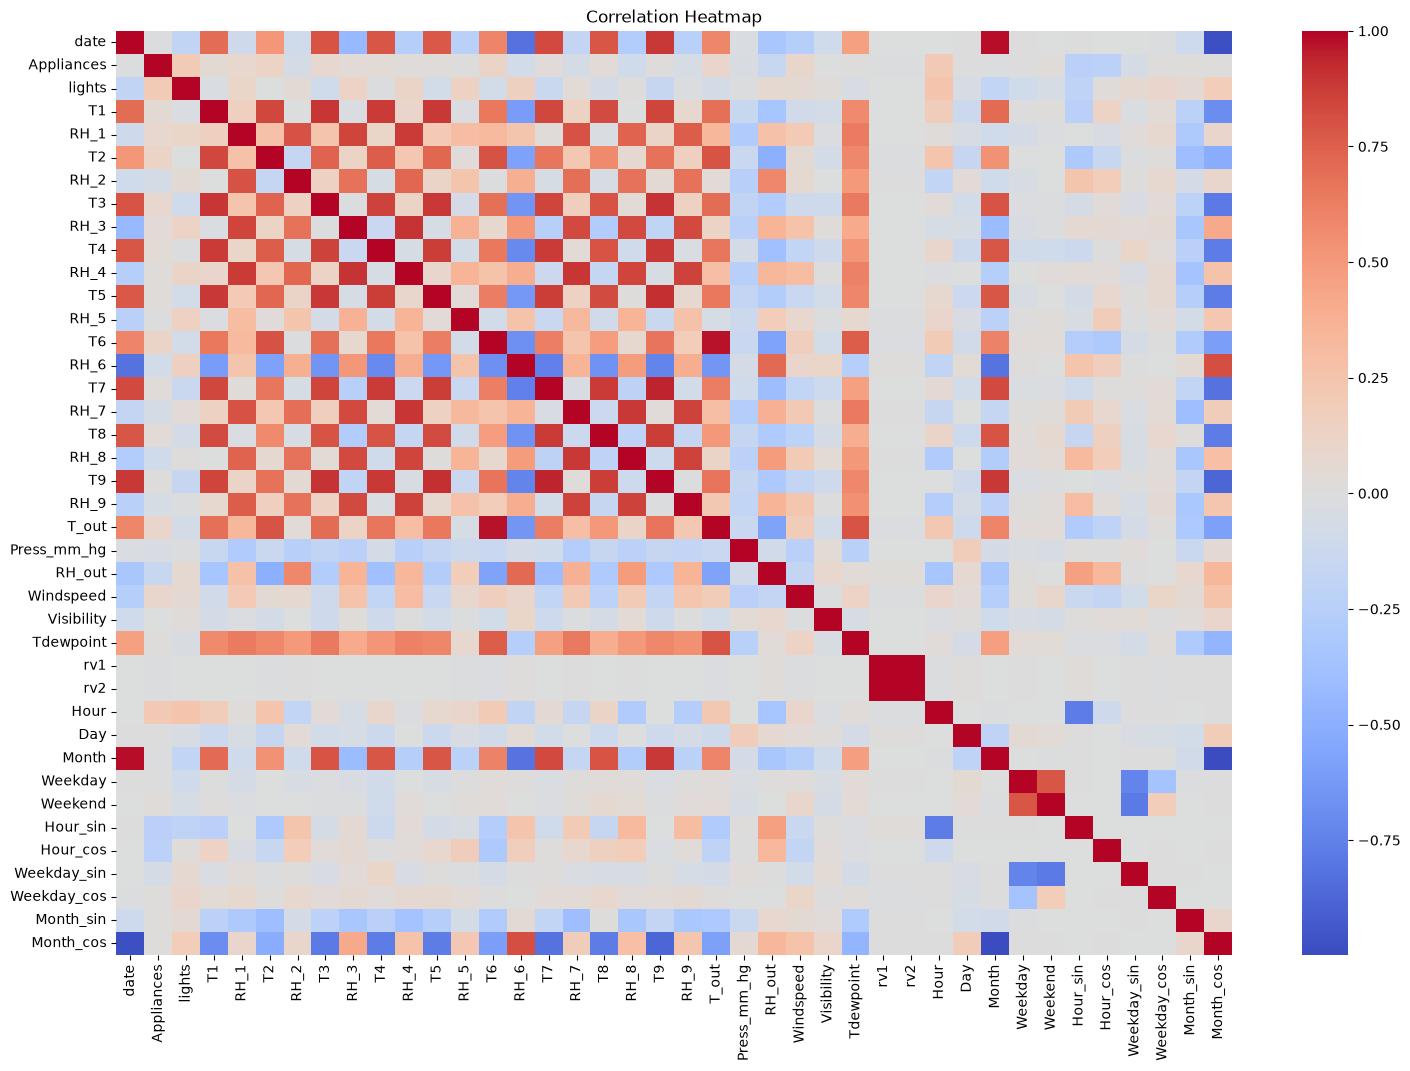

In [7]:
plt.figure(figsize=(18, 12))

sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

In [8]:
corr = df.corr()['Appliances'].sort_values(
    ascending=False
)

print(corr)

Appliances     1.000000
Hour           0.216792
lights         0.197278
T2             0.120073
T6             0.117638
T_out          0.099155
Windspeed      0.087122
RH_1           0.086031
T3             0.085060
T1             0.055447
T4             0.040281
T8             0.039572
RH_3           0.036292
T7             0.025801
T5             0.019760
Weekend        0.017437
RH_4           0.016965
Tdewpoint      0.015353
Month_sin      0.012703
Month_cos      0.011631
Weekday_cos    0.010717
T9             0.010010
RH_5           0.006955
Weekday        0.003060
Day            0.002366
Visibility     0.000230
date          -0.009630
rv1           -0.011145
rv2           -0.011145
Month         -0.011606
Press_mm_hg   -0.034885
RH_9          -0.051462
RH_7          -0.055642
Weekday_sin   -0.056045
RH_2          -0.060465
RH_6          -0.083178
RH_8          -0.094039
RH_out        -0.152282
Hour_cos      -0.232125
Hour_sin      -0.235233
Name: Appliances, dtype: float64


In [9]:
df = df.drop(columns=['rv1', 'rv2'])

print(df.columns)

Index(['date', 'Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3',
       'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8',
       'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed',
       'Visibility', 'Tdewpoint', 'Hour', 'Day', 'Month', 'Weekday', 'Weekend',
       'Hour_sin', 'Hour_cos', 'Weekday_sin', 'Weekday_cos', 'Month_sin',
       'Month_cos'],
      dtype='str')


In [10]:
X = df.drop('Appliances', axis=1)
y = df['Appliances']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (19735, 37)
y shape: (19735,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (15788, 37)
Testing data: (3947, 37)


In [12]:
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Linear Regression Results")
print("-------------------------")
print("R2 :", r2_score(y_test, y_pred))
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))

DTypePromotionError: The DType <class 'numpy.dtypes.DateTime64DType'> could not be promoted by <class 'numpy.dtypes.Float64DType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.DateTime64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64D

In [ ]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Results")
print("---------------------")
print("R2 :", r2_score(y_test, rf_pred))
print("MAE :", mean_absolute_error(y_test, rf_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, rf_pred)))

Random Forest Results
---------------------
R2 : 0.5673933223992349
MAE : 30.66617684317203
RMSE : 65.79615817546313


In [ ]:
et = ExtraTreesRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

et.fit(X_train, y_train)

et_pred = et.predict(X_test)

print("Extra Trees Results")
print("-------------------")
print("R2 :", r2_score(y_test, et_pred))
print("MAE :", mean_absolute_error(y_test, et_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, et_pred)))

Extra Trees Results
-------------------
R2 : 0.6358978863025135
MAE : 27.15590744024998
RMSE : 60.362264862341206


In [ ]:
param_grid = {
    'n_estimators': [200, 300, 500, 700],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

random_search = RandomizedSearchCV(
    estimator=ExtraTreesRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_

pred = best_model.predict(X_test)

print("Best Parameters:")
print(random_search.best_params_)

print("\nTuned Extra Trees Results")
print("-------------------------")
print("R2 :", r2_score(y_test, pred))
print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, pred)))

Best Parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 20}

Tuned Extra Trees Results
-------------------------
R2 : 0.6299980380847432
MAE : 27.66329103740519
RMSE : 60.84934952707219


In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(15))

      Feature  Importance
25       Hour    0.157681
5          T3    0.044115
0      lights    0.038292
2        RH_1    0.037540
6        RH_3    0.036377
4        RH_2    0.034604
21     RH_out    0.034086
22  Windspeed    0.033724
11         T6    0.031538
10       RH_5    0.031008
15         T8    0.030117
16       RH_8    0.029746
3          T2    0.029368
1          T1    0.029286
7          T4    0.029143


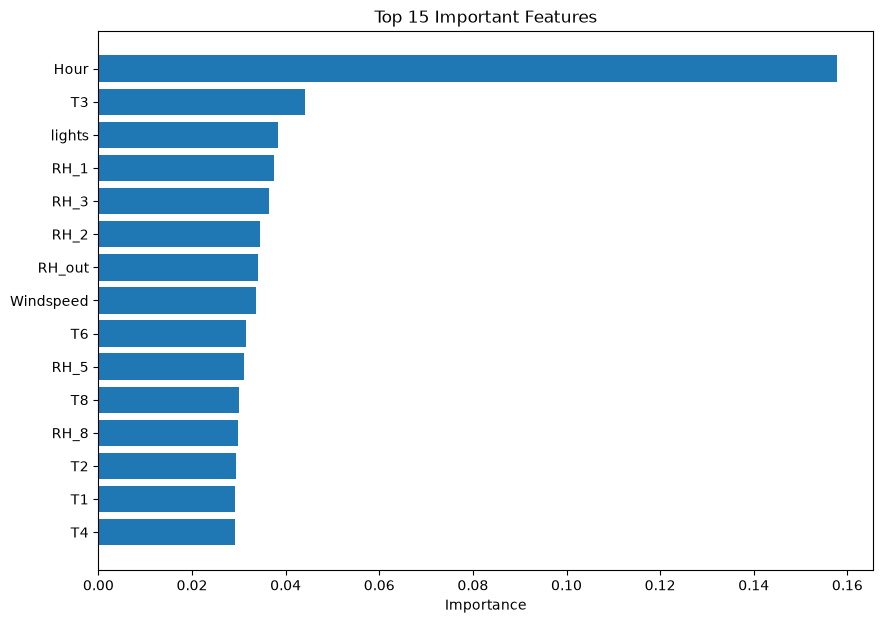

In [ ]:
plt.figure(figsize=(10, 7))

plt.barh(
    importance['Feature'].head(15),
    importance['Importance'].head(15)
)

plt.gca().invert_yaxis()

plt.title("Top 15 Important Features")
plt.xlabel("Importance")
plt.show()

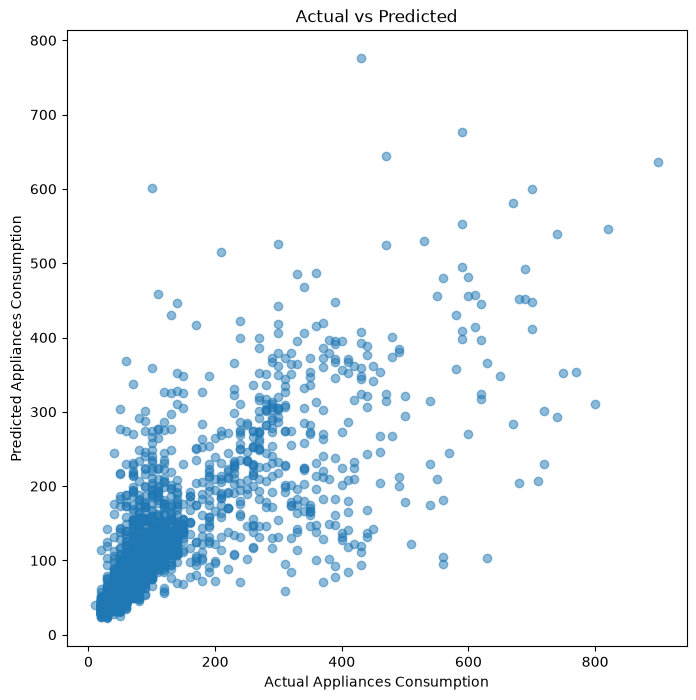

In [ ]:
plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    pred,
    alpha=0.5
)

plt.xlabel("Actual Appliances Consumption")
plt.ylabel("Predicted Appliances Consumption")
plt.title("Actual vs Predicted")

plt.show()

In [ ]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    random_state=42,
    objective="reg:squarederror"
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("XGBoost Results")
print("----------------")
print("R2 :", r2_score(y_test, xgb_pred))
print("MAE :", mean_absolute_error(y_test, xgb_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, xgb_pred)))

XGBoost Results
----------------
R2 : 0.589820146560669
MAE : 30.668581008911133
RMSE : 64.06798375919715


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Extra Trees",
        "Tuned Extra Trees",
        "XGBoost"
    ],

    "R2": [
        r2_score(y_test, y_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, et_pred),
        r2_score(y_test, pred),
        r2_score(y_test, xgb_pred)
    ],

    "MAE": [
        mean_absolute_error(y_test, y_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, et_pred),
        mean_absolute_error(y_test, pred),
        mean_absolute_error(y_test, xgb_pred)
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, et_pred)),
        np.sqrt(mean_squared_error(y_test, pred)),
        np.sqrt(mean_squared_error(y_test, xgb_pred))
    ]
})

results.sort_values(
    by="R2",
    ascending=False
)

,Model,R2,MAE,RMSE
2,Extra Trees,0.635898,27.155907,60.362265
3,Tuned Extra Trees,0.629998,27.663291,60.849350
4,XGBoost,0.589820,30.668581,64.067984
1,Random Forest,0.567393,30.666177,65.796158
0,Linear Regression,0.170653,52.565208,91.100799


In [ ]:
joblib.dump(
    best_model,
    "Best_Model.pkl"
)

print("Best model saved successfully!")

Best model saved successfully!


In [ ]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import shap

# Use only 100 observations so SHAP doesn't take forever
X_shap = X_test.sample(
    100,
    random_state=42
)

explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(
    X_shap,
    check_additivity=False
)

print("SHAP calculated successfully!")

c:\Users\garv\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP calculated successfully!


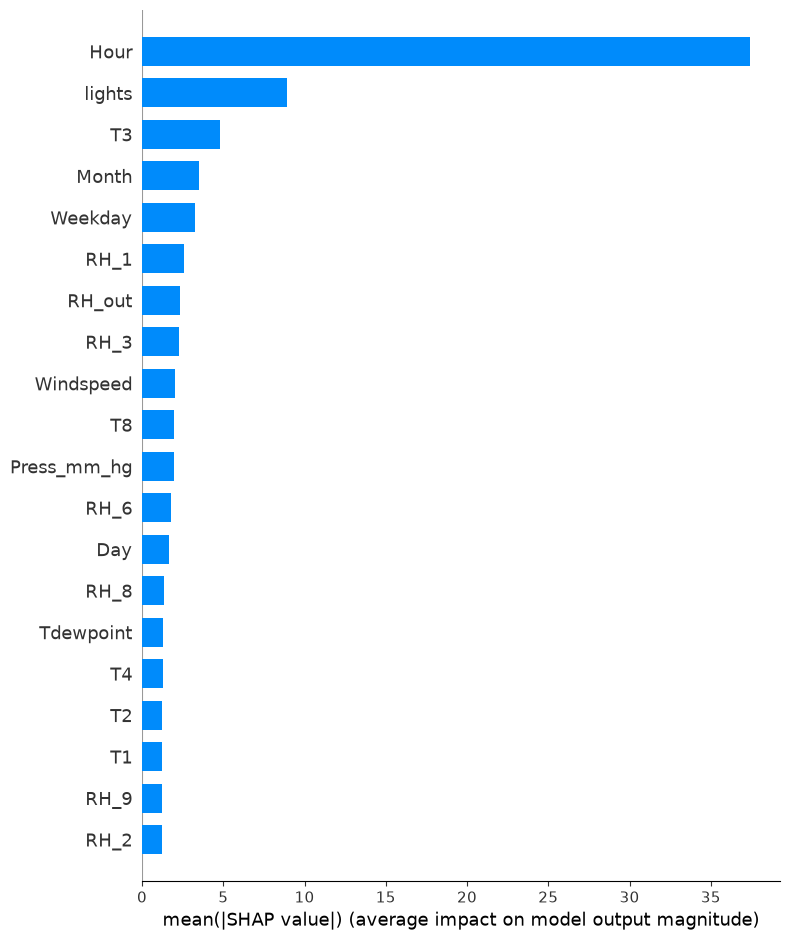

In [ ]:
shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar"
)

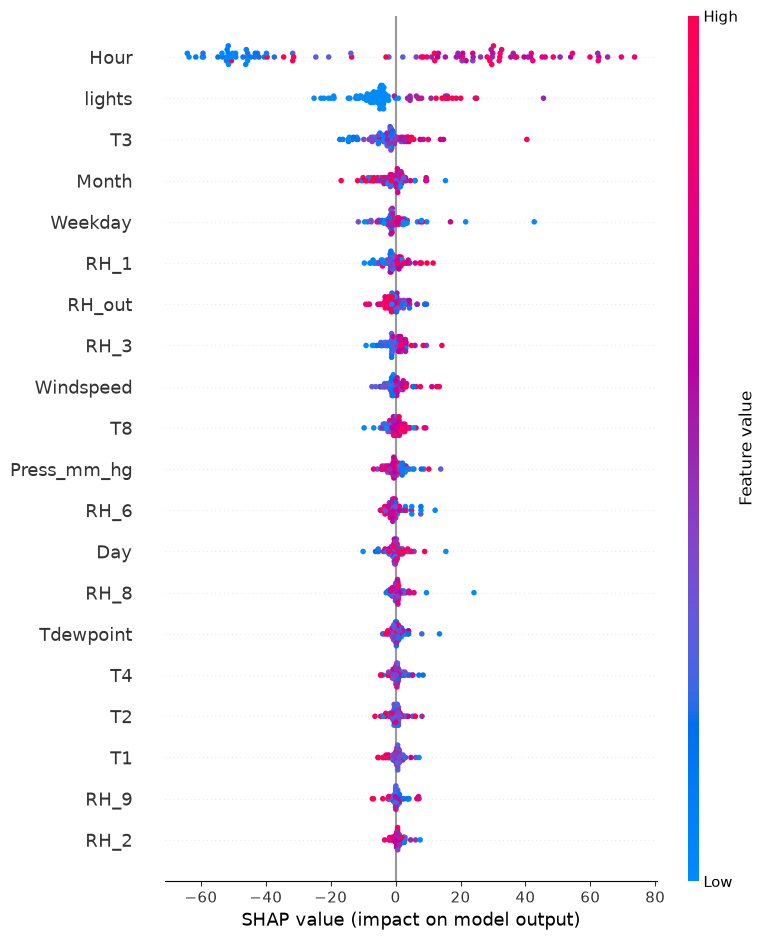

In [ ]:
shap.summary_plot(
    shap_values,
    X_shap
)

In [ ]:
print(X.dtypes[X.dtypes == 'datetime64[ns]'])

Series([], dtype: object)


In [ ]:
print(X.dtypes[X.dtypes == 'object'])

Series([], dtype: object)


In [ ]:
print(X.dtypes)

date           datetime64[us]
lights                  int64
T1                    float64
RH_1                  float64
T2                    float64
RH_2                  float64
T3                    float64
RH_3                  float64
T4                    float64
RH_4                  float64
T5                    float64
RH_5                  float64
T6                    float64
RH_6                  float64
T7                    float64
RH_7                  float64
T8                    float64
RH_8                  float64
T9                    float64
RH_9                  float64
T_out                 float64
Press_mm_hg           float64
RH_out                float64
Windspeed             float64
Visibility            float64
Tdewpoint             float64
Hour                    int32
Day                     int32
Month                   int32
Weekday                 int32
Weekend                 int64
Hour_sin              float64
Hour_cos              float64
Weekday_si

In [ ]:
# Remove date from the input features
X = X.drop(columns=['date'])

print(X.dtypes.head())
print("date" in X.columns)

lights      int64
T1        float64
RH_1      float64
T2        float64
RH_2      float64
dtype: object
False


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (15788, 36)
Testing data: (3947, 36)


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Linear Regression Results")
print("-------------------------")
print("R2 :", r2_score(y_test, y_pred))
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))

Linear Regression Results
-------------------------
R2 : 0.2041228579320643
MAE : 51.81135051176588
RMSE : 89.24357153518632


In [ ]:
X = X.drop(columns=['date'])

print("date" in X.columns)

KeyError: "['date'] not found in axis"

In [ ]:
print("date" in X.columns)
print("date" in X_train.columns)

False
False


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (15788, 36)
Testing data: (3947, 36)


In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Linear Regression Results")
print("R2 :", r2_score(y_test, y_pred))
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))

Linear Regression Results
R2 : 0.2041228579320643
MAE : 51.81135051176588
RMSE : 89.24357153518632


In [ ]:
et = ExtraTreesRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

et.fit(X_train, y_train)

et_pred = et.predict(X_test)

print("Extra Trees Results")
print("-------------------")
print("R2 :", r2_score(y_test, et_pred))
print("MAE :", mean_absolute_error(y_test, et_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, et_pred)))

Extra Trees Results
-------------------
R2 : 0.6341940075264973
MAE : 26.99214874869803
RMSE : 60.50333783714966


In [ ]:
df = df.drop(columns=[
    'Hour_sin',
    'Hour_cos',
    'Weekday_sin',
    'Weekday_cos',
    'Month_sin',
    'Month_cos'
])

In [ ]:
X = df.drop('Appliances', axis=1)
y = df['Appliances']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
param_grid = {
    'n_estimators': [300, 500, 700, 1000],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': [1.0, 'sqrt', 'log2', 0.7, 0.8]
}

random_search = RandomizedSearchCV(
    estimator=ExtraTreesRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=param_grid,
    n_iter=40,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_

pred = best_model.predict(X_test)

print("Best Parameters:")
print(random_search.best_params_)

print("\nTuned Extra Trees")
print("-----------------")
print("R2 :", r2_score(y_test, pred))
print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, pred)))

Fitting 5 folds for each of 40 candidates, totalling 200 fits


ValueError: 
All the 200 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
200 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\garv\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\garv\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\garv\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_forest.py", line 334, in fit
    X, y = validate_data(
           ^^^^^^^^^^^^^^
  File "c:\Users\garv\AppData\Local\Programs\Py